# import libraries and load data

In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_selection import chi2
from sentence_transformers import SentenceTransformer
import torch
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification, Trainer, TrainingArguments
from torch.utils.data import Dataset
from tqdm import tqdm
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('/kaggle/input/datasets/ssssws/spam-email-detection-dataset-clean-and-ml-ready/spam_email_dataset.csv')
df.shape

(10000, 20)

In [5]:
df.head(2)

,email_id,subject,email_text,num_words,num_characters,num_exclamation_marks,num_links,has_suspicious_link,num_attachments,has_attachment,sender_email,sender_domain,sender_reputation_score,email_hour,email_day_of_week,is_weekend,num_recipients,contains_money_terms,contains_urgency_terms,label
0,0,Weekly Report,budget review - Statement our I claim world st...,19,114,0,2,0,2,1,lctvdzm@outlook.com,outlook.com,0.66,19,3,0,23,0,0,0
1,1,Project Update,team sync - President series today already. In...,18,114,0,7,0,0,0,pxyldmi@company.com,company.com,0.95,4,4,0,16,1,0,0


# A quick overview of this dataset

Despite of all the info from the data card - 

## Q1: How many senders are in this dataset, and what are their domain? Are there any information in their domain?

In [6]:
len(df['sender_email'].unique())

10000

In [7]:
len(df['sender_domain'].unique())

8

In [8]:
df['sender_domain'].unique()

array(['outlook.com', 'company.com', 'unknownmail.cc', 'chealdealz.xyz',
       'yahoo.com', 'gmail.com', 'freemoney.biz', 'winbignow.ru'],
      dtype=object)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   email_id                 10000 non-null  int64  
 1   subject                  10000 non-null  object 
 2   email_text               10000 non-null  object 
 3   num_words                10000 non-null  int64  
 4   num_characters           10000 non-null  int64  
 5   num_exclamation_marks    10000 non-null  int64  
 6   num_links                10000 non-null  int64  
 7   has_suspicious_link      10000 non-null  int64  
 8   num_attachments          10000 non-null  int64  
 9   has_attachment           10000 non-null  int64  
 10  sender_email             10000 non-null  object 
 11  sender_domain            10000 non-null  object 
 12  sender_reputation_score  10000 non-null  float64
 13  email_hour               10000 non-null  int64  
 14  email_day_of_week      

In [10]:
df.groupby('sender_domain')['sender_reputation_score'].describe()

,count,mean,std,min,25%,50%,75%,max
sender_domain,,,,,,,,
chealdealz.xyz,1028.0,0.586994,0.157979,0.3,0.46,0.59,0.72,0.85
company.com,1454.0,0.753611,0.145032,0.5,0.63,0.76,0.88,1.00
freemoney.biz,1004.0,0.567620,0.159220,0.3,0.42,0.57,0.71,0.85
gmail.com,1531.0,0.753534,0.141370,0.5,0.64,0.75,0.87,1.00
outlook.com,1466.0,0.752449,0.146725,0.5,0.62,0.75,0.88,1.00
unknownmail.cc,989.0,0.577624,0.157616,0.3,0.44,0.58,0.71,0.85
winbignow.ru,974.0,0.574425,0.160404,0.3,0.44,0.57,0.71,0.85
yahoo.com,1554.0,0.748481,0.142289,0.5,0.62,0.75,0.87,1.00


In [11]:
df.groupby('sender_domain')['label'].mean()

sender_domain
chealdealz.xyz    1.0
company.com       0.0
freemoney.biz     1.0
gmail.com         0.0
outlook.com       0.0
unknownmail.cc    1.0
winbignow.ru      1.0
yahoo.com         0.0
Name: label, dtype: float64

In [12]:
df['label'].value_counts()

label
0    6005
1    3995
Name: count, dtype: int64

In [13]:
df.groupby('sender_domain').size()

sender_domain
chealdealz.xyz    1028
company.com       1454
freemoney.biz     1004
gmail.com         1531
outlook.com       1466
unknownmail.cc     989
winbignow.ru       974
yahoo.com         1554
dtype: int64

# Identifying the sender_domain

In [17]:
df_domain = pd.get_dummies(df['sender_domain'])
y = df['label']

In [18]:
df_domain

,chealdealz.xyz,company.com,freemoney.biz,gmail.com,outlook.com,unknownmail.cc,winbignow.ru,yahoo.com
0,False,False,False,False,True,False,False,False
1,False,True,False,False,False,False,False,False
2,False,False,False,False,False,True,False,False
3,True,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...
9995,False,False,False,False,False,True,False,False
9996,True,False,False,False,False,False,False,False
9997,False,False,False,False,False,True,False,False
9998,False,False,False,False,True,False,False,False


In [19]:
lr_model = LogisticRegression()
cross_val_score(lr_model, df_domain, y, scoring = 'roc_auc') # ROC AUC = how well model separates spam from ham (0.5 = random, 1.0 = perfect)

array([1., 1., 1., 1., 1.])

# Confusion matrix layout (for spam=1, ham=0):

* **Predicted**          **Ham**	**Predicted Spam**
* **Actual Ham**	     TN	    FP
* **Actual Spam**	     FN	    TP

In [20]:
X_tr, X_te, y_tr, y_te = train_test_split(df_domain, y)

lr_model.fit(X_tr, y_tr)
y_pred = lr_model.predict(X_te)

cm= confusion_matrix(y_pred, y_te)
cm

array([[1487,    0],
       [   0, 1013]])

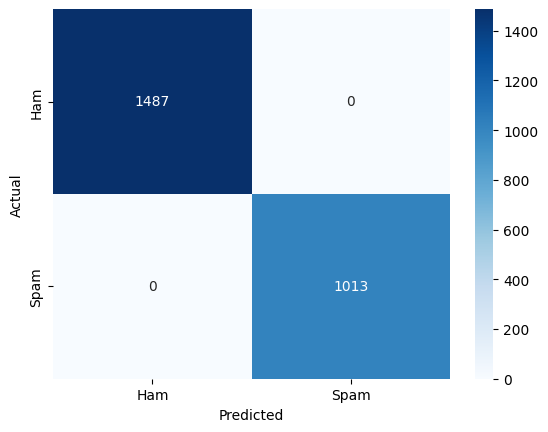

In [21]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Ham', 'Spam'], 
            yticklabels=['Ham', 'Spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [22]:
print(f"X_Train: \n{X_tr}\n X_Test: \n{X_te}\n y_Train: \n{y_tr}\n y_Test: \n{y_te}")

X_Train: 
      chealdealz.xyz  company.com  freemoney.biz  gmail.com  outlook.com  \
8512           False        False           True      False        False   
7417           False         True          False      False        False   
9345           False         True          False      False        False   
7202           False         True          False      False        False   
9393           False        False          False      False        False   
...              ...          ...            ...        ...          ...   
74             False        False          False      False        False   
1038           False        False          False      False        False   
3760           False         True          False      False        False   
8017           False        False          False      False         True   
5130            True        False          False      False        False   

      unknownmail.cc  winbignow.ru  yahoo.com  
8512           False         

It seems like our model can distinguish the spam and normal emails just by domain names, which is rare in real life. So let's move a step further - 

# Q2. What are some characteristics in spam emails?

In [23]:
vectorizer = CountVectorizer(stop_words='english', min_df=5)
X = vectorizer.fit_transform(df['email_text'])
chi_scores, _ = chi2(X, df['label'])

top_discriminative_words = [vectorizer.get_feature_names_out()[i] 
                  for i in chi_scores.argsort()[-10:]]
top_discriminative_reversed = []
for i in range(len(top_discriminative_words)-1, -1, -1):   # range(start, stop, step)
    top_discriminative_reversed.append(top_discriminative_words[i])

# top_discriminative_reversed = list(reversed(top_discriminative_words))   "to perform automaticaly"
print(f'Top 10 most discriminative words: {', '.join(top_discriminative_reversed)}')

Top 10 most discriminative words: urgent, guarantee, limited, win, click, cash, offer, free, schedule, sync


In [25]:
print("Number of top_discriminative_words:", len(top_discriminative_words))
print("Number of top_discriminative_reversed:", len(top_discriminative_reversed))

Number of top_discriminative_words: 10
Number of top_discriminative_reversed: 10


In [27]:
n_spam = df.loc[df['label']==1].shape[0]
n_normal = df.loc[df['label']==0].shape[0]
for w in top_discriminative_reversed:
    n_in_spam = df.loc[df['label']==1, 'email_text'].str.contains(w, case=False).sum()
    n_in_normal =  df.loc[df['label']==0, 'email_text'].str.contains(w, case=False).sum()
    if n_in_spam/n_spam > n_in_normal/n_normal:
     print(f'"{w}" is SPAM indicator')
    else:
     print(f'"{w}" is HAM indicator')
    print(f'Percentage of "{w}" in spam: {n_in_spam/n_spam}')
    print(f'Percentage of "{w}" in ham: {n_in_normal/n_normal}')
    print('--------------------------------------------------')

"urgent" is SPAM indicator
Percentage of "urgent" in spam: 0.7198998748435544
Percentage of "urgent" in ham: 0.0
--------------------------------------------------
"guarantee" is SPAM indicator
Percentage of "guarantee" in spam: 0.7181476846057572
Percentage of "guarantee" in ham: 0.0
--------------------------------------------------
"limited" is SPAM indicator
Percentage of "limited" in spam: 0.7143929912390488
Percentage of "limited" in ham: 0.0
--------------------------------------------------
"win" is SPAM indicator
Percentage of "win" in spam: 0.7196495619524406
Percentage of "win" in ham: 0.041465445462114905
--------------------------------------------------
"click" is SPAM indicator
Percentage of "click" in spam: 0.7036295369211515
Percentage of "click" in ham: 0.0
--------------------------------------------------
"cash" is SPAM indicator
Percentage of "cash" in spam: 0.7076345431789737
Percentage of "cash" in ham: 0.0
--------------------------------------------------
"offe

# Q3. Can we visualize the clusters between spam and ham?

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


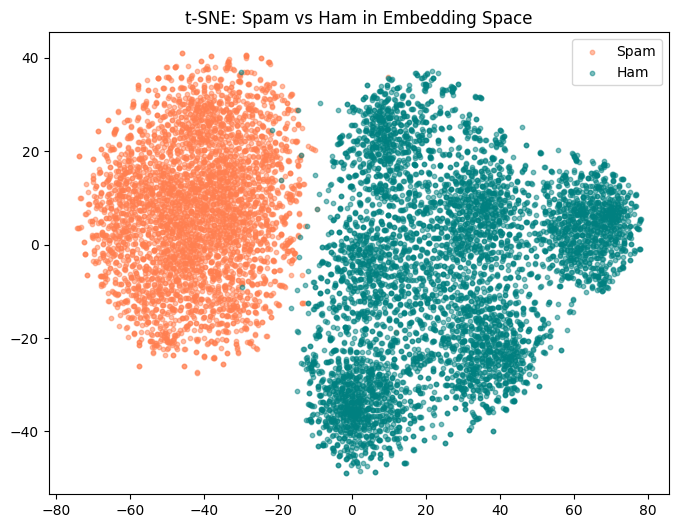

In [29]:
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(df['email_text'].tolist())

tsne = TSNE(n_components=2, random_state=42)
embed_2d = tsne.fit_transform(embeddings)

plt.figure(figsize=(8, 6))
plt.scatter(embed_2d[df['label']==1, 0], embed_2d[df['label']==1, 1], 
            c='coral', alpha=0.5, label='Spam', s=10)
plt.scatter(embed_2d[df['label']==0, 0], embed_2d[df['label']==0, 1], 
            c='teal', alpha=0.5, label='Ham', s=10)
plt.legend()
plt.title('t-SNE: Spam vs Ham in Embedding Space')
plt.show()

# DistilBERT Model

In [30]:
# Ensure labels are integers: 0 = ham, 1 = spam
if df['label'].dtype == object:
    df['label'] = df['label'].map({'ham': 0, 'spam': 1})
# Split your dataset - adjust test_size as needed
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['email_text'].values, df['label'].values, test_size=0.2, random_state=42
)

# 2. DEFINE CUSTOM DATASET CLASS FOR PYTORCH


In [31]:
class SpamDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# 3. INITIALIZE TOKENIZER AND MODEL


In [32]:
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


# 4. CREATE DATASET OBJECTS

In [33]:
train_dataset = SpamDataset(train_texts, train_labels, tokenizer)
val_dataset = SpamDataset(val_texts, val_labels, tokenizer)

# 5. SET TRAINING ARGUMENTS

In [34]:
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=64,
    warmup_steps=500,
    weight_decay=0.01,
    logging_steps=10,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    report_to="none",  # or "tensorboard" if you want logs
)

# 6. SET UP TRAINER AND TRAIN MODEL

In [35]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
)

trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss
1,0.001845,0.001321
2,0.000188,0.000123
3,0.000081,0.000051


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=750, training_loss=0.11360024385526776, metrics={'train_runtime': 182.6375, 'train_samples_per_second': 131.408, 'train_steps_per_second': 4.106, 'total_flos': 794804391936000.0, 'train_loss': 0.11360024385526776, 'epoch': 3.0})

# 7. EVALUATE ON VALIDATION SET

In [36]:
predictions = trainer.predict(val_dataset)
preds = np.argmax(predictions.predictions, axis=-1)

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


# 8. SHOW RESULTS

In [39]:
print("\n✅ Accuracy:", accuracy_score(val_labels, preds))
print("\n📊 Classification Report:\n", classification_report(val_labels, preds, target_names=['Ham', 'Spam']))


✅ Accuracy: 1.0

📊 Classification Report:
               precision    recall  f1-score   support

         Ham       1.00      1.00      1.00      1181
        Spam       1.00      1.00      1.00       819

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



# 9. PLOT CONFUSION MATRIX

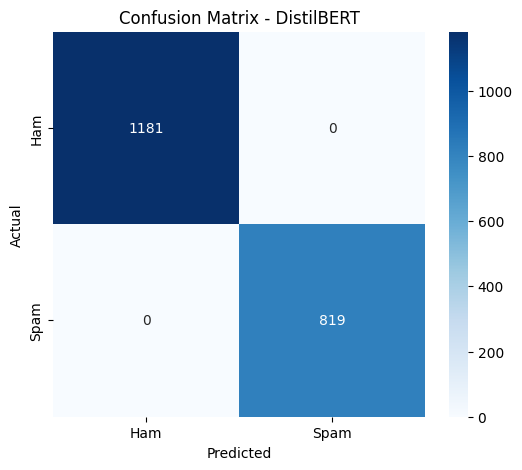

In [40]:
cm = confusion_matrix(val_labels, preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.title('Confusion Matrix - DistilBERT')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()